**Project Description**

This project focuses on performing Exploratory Data Analysis (EDA) on an Amazon sales dataset to uncover meaningful insights related to customer behavior, product performance, and revenue trends. The dataset includes information such as product categories, pricing, discounts, customer regions, payment methods, ratings, and total revenue.

The analysis begins with data cleaning and preprocessing, where missing values, duplicates, and inconsistent text formats are handled to ensure data quality. This is followed by a detailed univariate and bivariate analysis using visualizations such as bar charts, line plots, and pie charts created with Matplotlib.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **DATA LOADING**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aliiihussain/amazon-sales-dataset/amazon_sales_dataset.csv")

# **DATA EXPLORATION**

In [3]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [6]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [7]:
df.shape

(50000, 13)

In [8]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [9]:
# Unique Product Categories
df["product_category"].nunique()

6

In [11]:
# Name of unique product categories
df['product_category'].unique()

array(['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics',
       'Home & Kitchen'], dtype=object)

In [12]:
# Total quantity of sold products

df['quantity_sold'].sum()

np.int64(149970)

In [13]:
#Payment methods
df['payment_method'].unique()

array(['UPI', 'Credit Card', 'Wallet', 'Cash on Delivery', 'Debit Card'],
      dtype=object)

In [15]:
#value counts
df['payment_method'].value_counts()

payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64

# **DATA VIZUALISATION**

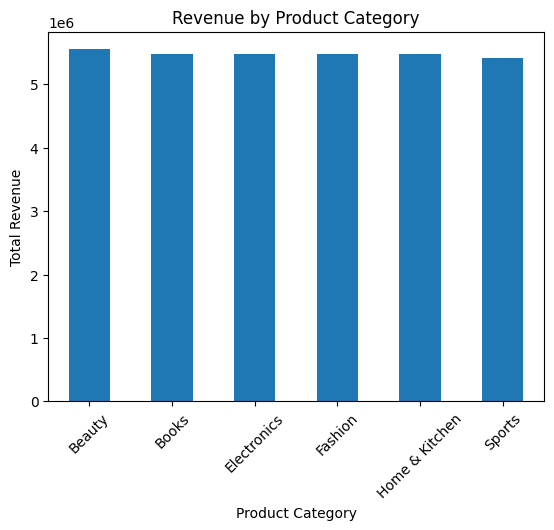

In [16]:
#Product Category vs Revenue

category_revenue = df.groupby('product_category')['total_revenue'].sum()

plt.figure()
category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


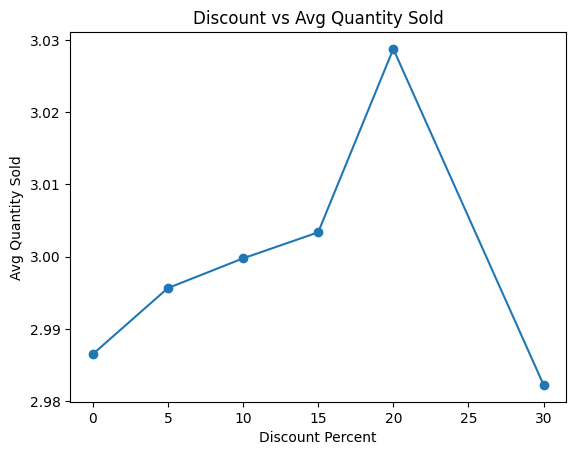

In [18]:
#Discount vs Quantity Sold (Trend)

discount_sales = df.groupby('discount_percent')['quantity_sold'].mean()

plt.figure()
discount_sales.plot(kind='line', marker='o')

plt.title("Discount vs Avg Quantity Sold")
plt.xlabel("Discount Percent")
plt.ylabel("Avg Quantity Sold")
plt.show()

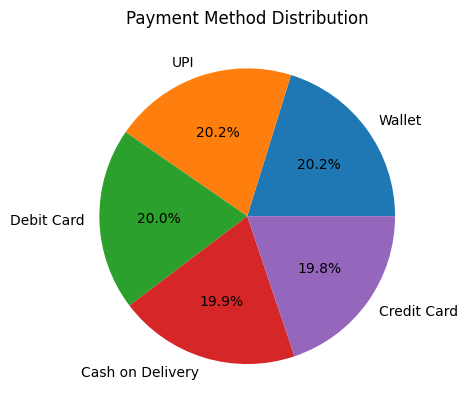

In [19]:
# Payment Method Distribution

payment_counts = df['payment_method'].value_counts()

plt.figure()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

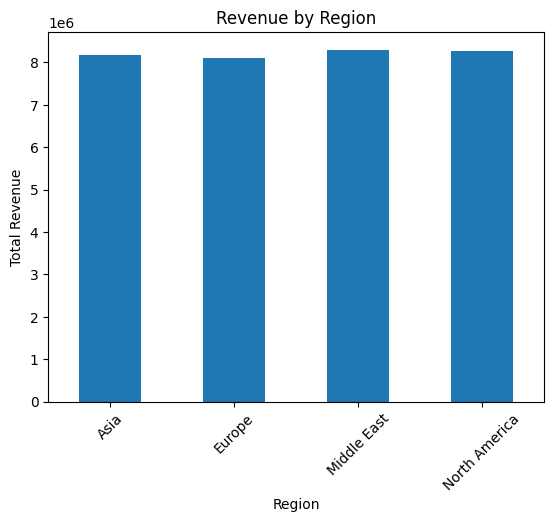

In [20]:
#Region-wise Revenue

region_revenue = df.groupby('customer_region')['total_revenue'].sum()

plt.figure()
region_revenue.plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

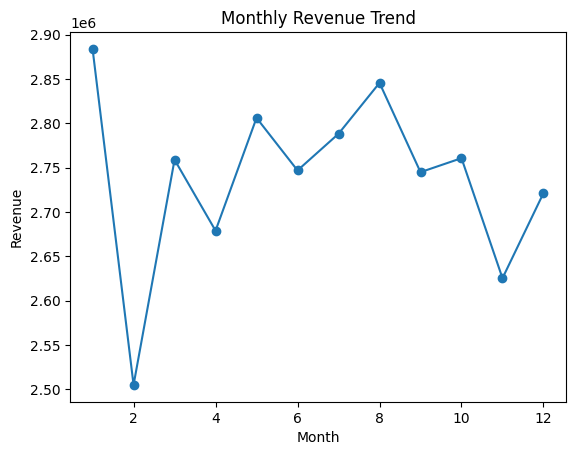

In [23]:
# Monthly Revenue trend

df['order_date'] = pd.to_datetime(df['order_date'])

monthly_revenue = df.groupby(df['order_date'].dt.month)['total_revenue'].sum()

plt.figure()
monthly_revenue.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

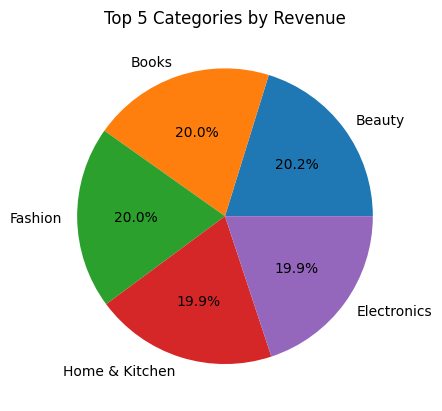

In [25]:
# Top 5 Categories

top_categories = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).head(5)

plt.figure()
plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%')
plt.title("Top 5 Categories by Revenue")
plt.show()